# Examen Data Science & AI

| | |
| :--- | :--- |
| **Student Voornaam:** |Jasper |
| **Student Familienaam:** | Haegeman |
| **Studentennummer:** | VUL HIER JE STUDENTENNUMMER IN |
| **Datum & uur:** | Maandag 2 september 2014, 12:30 |
| **Klasgroep:** | 2A |
| **IOEM-student:** | JA |

Voeg waar nodig codecellen toe voor het uitwerken van de vragen. LET OP! De inhoud van de codeblokken wordt niet als antwoord beschouwd! Enkel wat je in de daarvoor voorziene Markdown-cellen noteert telt als antwoord! De inhoud van de codeblokken dient enkel om je antwoord te staven, zodat we kunnen zien hoe je tot je antwoord gekomen bent als het niet zou overeenkomen met de verwachte uitkomst.


Het examen staat in totaal op 40 punten.

In [3]:
# Importeren van de nodige packages
# Vul zelf aan met extra packages als dit nodig is voor de oefeningen!
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\32468\AppData\Local\Temp\ipykernel_26140\3083441694.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Vraag 1 [2 pt]

Wat is het meetniveau van elk van deze variabelen:

1. [0.5 pt] de titel van een dokter: huisarts, geneesheer-specialist, professor in de oncologie, ...
2. [0.5 pt] of een arts wel of niet geconventioneerd is
3. [0.5 pt] het aantal euro dat een arts vraagt voor een eenvoudige consultatie
4. [0.5 pt] de specialisatie van een arts: oncologie, hart- en vaatziekten, oogarts, ...

### Antwoord vraag 1

1. nominaal
2. nominaal
3. ratio
4. ordinaal

## Vraag 2 [3 pt]

In een groot bedrijf heeft men een thema-avond met een gastspreker georganiseerd. Om de organisatie van dit soort thema-avonden verder te verfijnen en zo veel mogelijk werknemers op deze manier te proberen bereiken, heeft men elke aanwezige na afloop een Google formulier toegestuurd via e-mail. Via dit formulier kon de werknemer de gastspreker en de thema-avond een score geven tussen 1 en 5.
1. [1 pt] Is dit een random sample? Leg uit.
2. [1 pt] Welk type fout(en) wordt hier gemaakt?
3. [1 pt] Is dit een goede sample? Leg uit.

### Antwoord vraag 2

1. Dit is geen aselecte steekproef. Niet alle werknemers hebben evenveel kans om geselecteerd te worden, enkel zij met een e-mailadres.
2.  Systematische steekproeffout, enkel werknemers met een e-mailadres worden bevraagd.
3. Nee, want er wordt een systematische steekproeffout gemaakt. Op deze manier zal de steekproef niet representatief zijn.

## Vraag 3 [3 pt]

Jan is lid van een schietclub. De kans dat hij het target raakt, is 25%. Dit is onafhankelijk van het feit of hij de vorige keer het target al dan niet geraakt heeft. Hij vuurt vier keer af.

1. [1 pt] Wat is de kans dat Jan ten minste 1 keer het target raakt?
2. [1 pt] Wat is de kans dat Jan exact 2 keer het target raakt?
3. [1 pt] Wat is de kans dat Jan ten minste 3 keer het target raakt?

### Antwoord vraag 3

1. P(kans target 1x raken) = 0.25
2. P(geen kans eerste target) = 1 - 0.25 = 0.50
3. P(0.75)

## Vraag 4 [4 pt]
De vulhoeveelheid van flessen frisdrank is normaal verdeeld, met een gemiddelde van 2,0 liter en een standaardafwijking van 0,05 liter. Als flessen minder dan 95% van de vermelde netto-inhoud bevatten (in dit geval 1,90 liter), kan de fabrikant een boete krijgen . Flessen met een netto inhoud van meer dan 2,10 liter kunnen overmatig morsen bij het openen. Welk deel van de flessen bevat
1. [1 pt] tussen 1,90 en 2,0 liter?
2. [1 pt] minder dan 1,90 liter of meer dan 2,10 liter?
3. [1 pt] 99% van de flessen bevat minstens hoeveel frisdrank?
4. [1 pt] 99% van de flessen bevat een hoeveelheid die tussen welke twee waarden (symmetrisch verdeeld) rond het gemiddelde ligt?

In [8]:
mu = 2.0
sigma = .05

In [3]:
stats.norm.cdf(2.0, loc=mu, scale=sigma) - stats.norm.cdf(1.90, loc=mu, scale=sigma)

0.4772498680518209

In [6]:
x = stats.norm.cdf(1.90, loc=mu, scale=sigma)
y = stats.norm.sf(2.10, loc=mu, scale=sigma)

print(f'Minder dan 1.90: %.4f' % x)
print(f'Meer dan 2.10: %.4f' % y)

Minder dan 1.90: 0.0228
Meer dan 2.10: 0.0228


In [9]:
stats.norm.isf(0.01, loc=mu, scale=sigma)

2.116317393702042

### Antwoord vraag 4

1. 47.72%
2. 2.28%
3. 2.12 frisdrank
4. ...

## Vraag 5 [5 pt]
Een lokale pizzeria beweert dat zij sneller pizza's kunnen leveren dan een lokale vestiging van een grote keten. Om dit te controleren heb je bij beiden 10 keer pizza's besteld. Hieronder staan de tijden (in minuten) die ze nodig hadden. Kan de lokale pizzeria inderdaad significant sneller pizza's leveren dan de grote speler?

1. [1 pt] Maak een plot
2. [1 pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
3. [1 pt] Formuleer de nulhypothese en de alternatieve hypothese
4. [1 pt] Bereken de p-waarde
5. [1 pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.

In [19]:
dfpizzas = pd.DataFrame(data= {'lokaal': [16.8, 11.7, 15.6, 16.7, 17.5, 18.1, 14.1, 21.8, 13.9, 20.8],
                               'keten': [22.0, 15.2, 18.7, 15.6, 20.8, 19.5, 17.0, 19.5, 16.5, 24.0]})

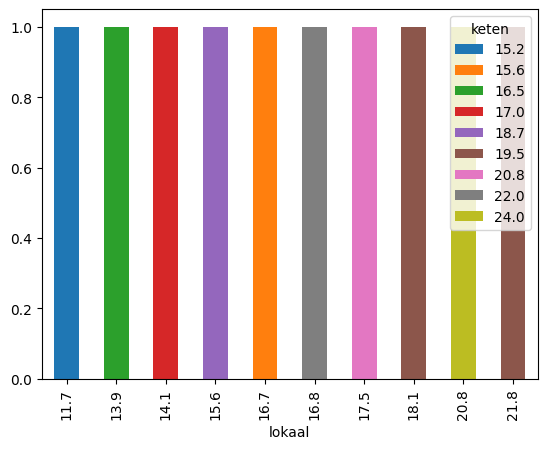

In [20]:

dfpizzas = pd.crosstab(dfpizzas.lokaal, dfpizzas.keten)
dfpizzas.plot(kind='bar', stacked=True);

In [12]:
chi2, p, dof, expected = stats.chi2_contingency(dfpizzas)

print(f'chi-squared : %.4f' % chi2)
print(f'P-value : %.4f' % p)
print(f'Degrees of Freedom  : %d' % dof)

chi-squared : 1.3251
P-value : 0.9982
Degrees of Freedom  : 9


### Antwoord vraag 5

1. (Genereer de plot hierboven in een codecel. Geef duidelijk aan dat de plot bij deze deelvraag hoort!)
2. Chi-kwadraattoets voor onafhankelijkheid
3. $H_0$: Er is geen verschil tussen lokaal en keten qua snelheid, $H_1$= Er is een duidelijk een verschil tussen lokaal en keten qua snelheid.
4. $P$ = 0.9982
5. Er is duidelijk een verschil tussen lokaal en keten qua snelheid.


## Vraag 6 [7 pt]
De remafstand (in meter) werd gemeten van een vrachtwagen die onder specifieke omstandigheden rijdt aan 32 km/uur. Het rapport stelde dat onder deze omstandigheden de maximum toegelaten remafstand 9.15 meter is. De remafstand is normaal verdeeld. Suggereren de hieronder gemeten waarde dat de werkelijke remafstand groter is dan 9.15 meter? Voer een test uit met 1% significance level om deze vraag te beantwoorden.

1. [1 pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
2. [1 pt] Formuleer de nulhypothese en de alternatieve hypothese
3. [1 pt] Bereken de gepaste toetsingsgrootheid (teststatistiek) voor deze toets. Geef het symbool en de waarde
4. [1 pt] Bereken de p-waarde
5. [1 pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.
6. [2 pt] Wat is de kans op een Type II fout bij 1% significance level wanneer in werkelijkheid $\mu = 9.35$?

In [25]:
remafstand = np.array([9.78, 9.33, 9.57, 9.26, 9.45, 9.72])

In [4]:
mu = 9.15
alpha = 0.01
n = len(remafstand)
s_sample = remafstand.std(ddof=1)
m_sample = remafstand.mean()

t = stats.t.isf(1-alpha, df=n-1)
p = stats.t.cdf(m_sample, loc=mu,scale = s_sample/np.sqrt(n), df=n-1)

print(f'sample mean: %.4f' % m_sample)
print(f't-score: %.4f' % t)
print(f'P-value: %.4f' % p)

NameError: name 'remafstand' is not defined

### Antwoord vraag 6

1. One-sample t-test
2. Hypothesen:
$H_0$ : mu = 9.15 ()
$H_1$: mu < 9.15 ()
3. $\overline{x}$ = 9.5183
4. $p = 0.9962
5. $p >> \alpha$. == 0.01, dus we verwerpen de nulhypothese niet. Op basis van de steekproef is er dus inderdaad een grotere remafstand. 
6. 


## Vraag 7 [4 pt]
Criminologen hebben lang gedebatteerd over de vraag of er een verband is tussen weersomstandigheden en het aantal gepleegde misdrijven. In 1988 verscheen er een artikel "Is there a
Season for Homicide?" (Criminologie, 1988: 287-296) dat 1361 moorden classificeerde op basis van het seizoen, wat resulteerde in
in de onderstaande gegevens.  
Is er een associatie tussen het seizoen en het aantal gepleegde moorden?

1. [1 pt] Welke hypothesetoets ga je toepassen om deze onderzoeksvraag te beantwoorden? Wees zo specifiek mogelijk!
2. [1 pt] Formuleer de nulhypothese en de alternatieve hypothese
3. [1 pt] Bereken de p-waarde
4. [1 pt] Trek een besluit op basis van de vorige stap en formuleer een antwoord op de onderzoeksvraag.

In [5]:
dfmoorden = pd.DataFrame(data={
    'seizoen': ['winter', 'lente','zomer','herfst'],
    'aantal_moorden': [328, 334, 372, 327]
})

In [ ]:
stats.ttest_ind(a=dfmoorden.seizoen, b=dfmoorden.aantal_moorden,
    alternative='less')
p

### Antwoord vraag 7

1. Independent two-sample T-test
2. ...
3. ...
4. ...


## Vraag 8 [11 pt]
Hieronder staat de pachtprijs van beteelde gronden (EUR/ha) in België.  
Bron = StatBel

1. [1 pt] Maak de onderstaande plot.
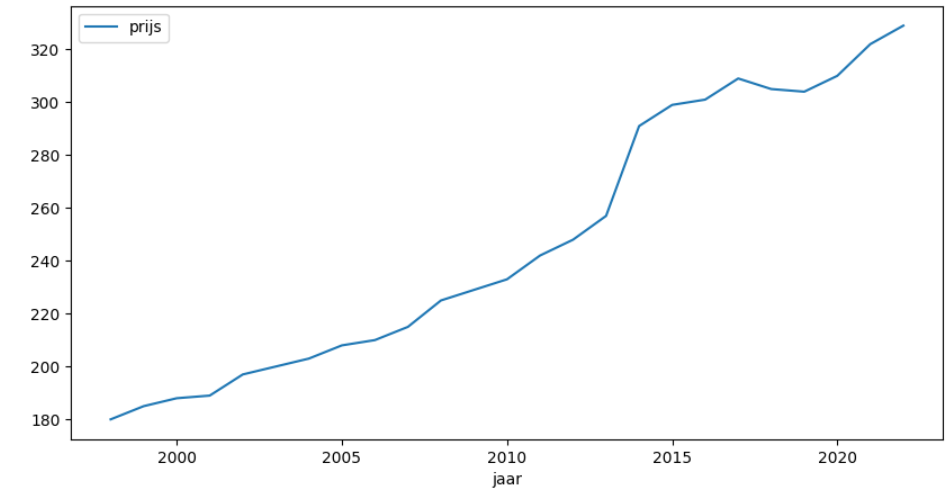
2. [1 pt] Splits de data op in trainingsdata (1998 tot en met 2018) en testdata (2019 tot en met 2022)
3. [1 pt] Train een eerste geschikt model op de trainingsdata.
4. [1 pt] Maak gebruik van dit eerste model om voorspellingen te doen voor de testdata.
5. [1 pt] Train een tweede (ander) geschikt model op de trainingsdata.
6. [1 pt] Maak gebruik van dit tweede model om voorspellingen te doen voor de testdata.
7. [1 pt] Bepaal welk van de beide modellen het best presteert op de testdata.
8. [1 pt] Hoeveel bedroeg de gemiddelde pachtprijs tussen het jaar 2010 en 2020 (grenzen inclusief)?
9. [1 pt] In welk jaar ging de pachtprijs voor het eerst door de 300 EUR grens? (Berekenen, niet gewoon aflezen!)  
"De pachtprijs ging in het jaar ... door de 300 EUR grens."
10. [2 pt] Bereken de gemiddelde procentuele stijging per jaar over alle jaren heen.


In [7]:
dfpacht = pd.DataFrame(data={
    'jaar': [1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022],
    'prijs': [180, 185, 188, 189, 197, 200, 203, 208, 210, 215, 225, 229, 233, 242, 248, 257, 291, 299, 301, 309, 305, 304, 310, 322, 329]
}).set_index('jaar')
dfpacht.head()

,prijs
jaar,
1998,180
1999,185
2000,188
2001,189
2002,197


<Axes: xlabel='jaar'>

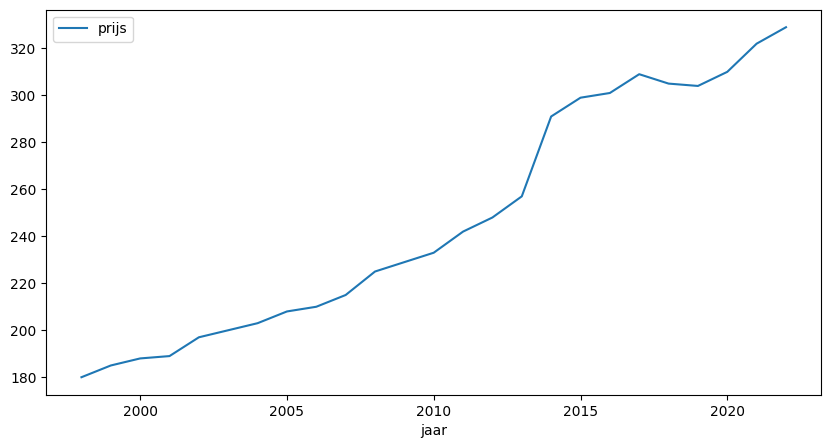

In [8]:
#plot
dfpacht.plot(y='prijs', figsize=[10,5])

In [ ]:
dfrestaurants[(dfrestaurants.prijs > 65) & (dfrestaurants.locatie == 'NYC')]['naam'].count()

In [ ]:
dfpacht['trainingdata'] = dfpacht[(dfpacht['jaar'].count() <= 2019 )]
dfpacht.head()

In [ ]:
dfpacht['testdata'] = dfpacht[(dfpacht['jaar'].count() >= 2019 )]

### Antwoord vraag 8

1. (Genereer de plot hierboven in een codecel. Geef duidelijk aan dat de plot bij deze deelvraag hoort!)
2. ...
3. ...
4. ...
5. ...
6. ...
7. ...
8. ...
9. ...
10. ...

## Vraag 9 [2 pt]
Bij de productie vallen machines soms uit. Het aantal keer dat een machine uitvalt per week wordt in een specifiek bedrijf als volgt beschreven:

| | | | | | |  
| :--- | :--- | :--- | :--- | :--- | :--- |  
| **Aantal _x_** | 0 | 1 | 2 | 3 | 4 |  
| **_P(X = x)_** | 0.5 | 0.26 | 0.12 | 0.08 | 0.04 |  

1. [1 pt] Wat is het verwachte aantal storingen per week?
2. [1 pt] Iedere keer dat een machine uitvalt, kost het ca. 10000 EUR aan het bedrijf (herstellingskosten, stillegen van de productie, ...). Bereken de verwachte storingskosten per jaar.

### Antwoord vraag 9

1. P = 1
2. (0*0.5 + 10000*0.26 + 20000*0.12 + 30000*0.08 + 40000+0.04) * 52 =  2 464 802.08 euro


In [53]:
(0*0.5 + 10000*0.26 + 20000*0.12 + 30000*0.08 + 40000+0.04) * 52

2464802.08